# Stock Price Trend Prediction — LSTM

**Project:** University deep learning assignment
**Area:** Time Series · **Concepts:** LSTM, sequence modeling
**Target:** AAPL daily Close price (2014 → today, via `yfinance`)

> Educational only. **Not financial advice.**

## Workflow
1. Fetch + cache OHLCV data
2. EDA — price, moving averages, returns distribution
3. Preprocess — MinMax scaling, sliding-window sequences
4. Train LSTM (2 layers + dropout)
5. Evaluate on chronological test split (RMSE / MAE / MAPE)
6. 30-day autoregressive forecast

In [1]:
import sys, pathlib
ROOT = pathlib.Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

import config
from src.data_loader import load_stock
from src.preprocess import prepare_training_data
from src.model import build_lstm
from src.utils import rmse, mae, mape, forecast_future

plt.rcParams['figure.figsize'] = (11, 4)
sns.set_style('whitegrid')
print('TF', tf.__version__)

TF 2.21.0


## 1. Load Data
Uses `yfinance` to fetch AAPL OHLCV. Cached to `artifacts/data/AAPL.csv` on first call.

In [2]:
df = load_stock('AAPL', start='2014-01-01')
print(f'Shape: {df.shape}')
print(f'Range: {df.index.min().date()} -> {df.index.max().date()}')
df.tail()

Shape: (3115, 6)
Range: 2014-01-02 -> 2026-05-21


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-05-15,300.230011,300.230011,303.200012,296.519989,297.899994,54862800
2026-05-18,297.839996,297.839996,300.660004,294.910004,300.239990,34483000
2026-05-19,298.970001,298.970001,300.510010,296.350006,296.970001,42243600
2026-05-20,302.250000,302.250000,302.799988,298.079987,298.179993,38229800
2026-05-21,304.989990,304.989990,305.540009,300.399994,301.059998,42900600


## 2. Exploratory Data Analysis

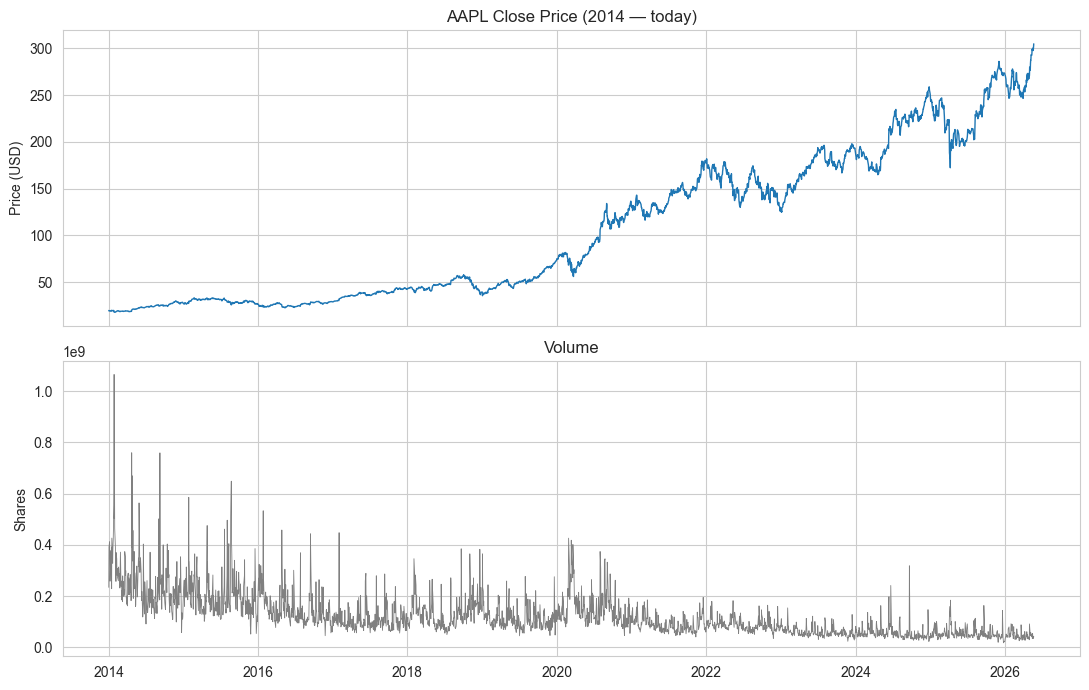

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(df.index, df['Close'], lw=1)
axes[0].set_title('AAPL Close Price (2014 — today)')
axes[0].set_ylabel('Price (USD)')
axes[1].plot(df.index, df['Volume'], lw=0.6, color='gray')
axes[1].set_title('Volume')
axes[1].set_ylabel('Shares')
plt.tight_layout()

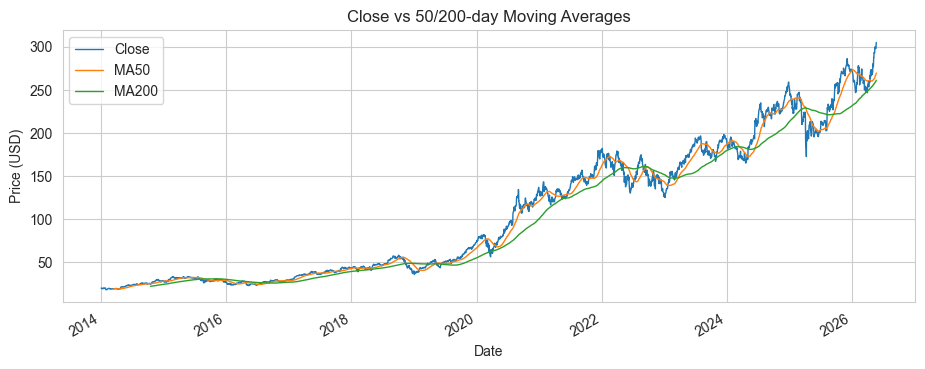

In [4]:
df_ma = df[['Close']].copy()
df_ma['MA50']  = df_ma['Close'].rolling(50).mean()
df_ma['MA200'] = df_ma['Close'].rolling(200).mean()
df_ma.plot(title='Close vs 50/200-day Moving Averages', lw=1)
plt.ylabel('Price (USD)');

Mean daily return: 0.104%   Std: 1.776%


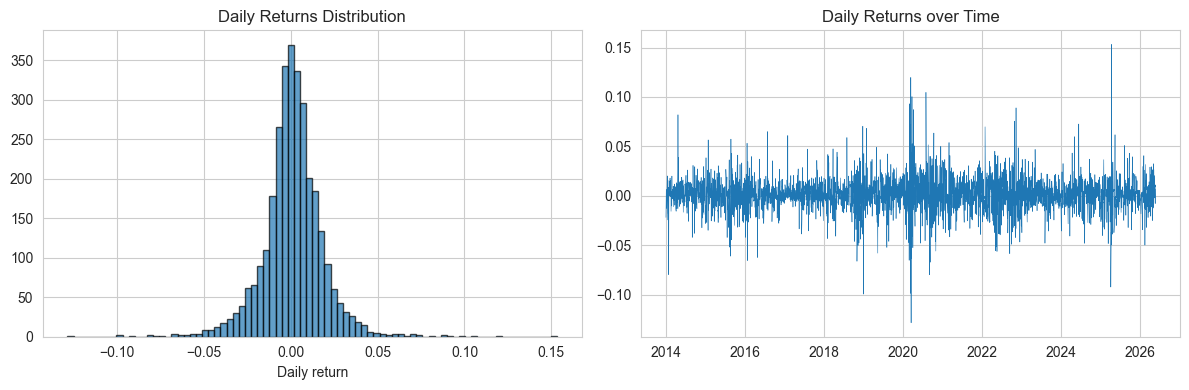

In [5]:
returns = df['Close'].pct_change().dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(returns, bins=80, edgecolor='k', alpha=0.7)
axes[0].set_title('Daily Returns Distribution')
axes[0].set_xlabel('Daily return')
axes[1].plot(returns.index, returns, lw=0.4)
axes[1].set_title('Daily Returns over Time')
plt.tight_layout()
print(f'Mean daily return: {returns.mean()*100:.3f}%   Std: {returns.std()*100:.3f}%')

## 3. Preprocess
- Use **Close** as univariate target.
- `MinMaxScaler(0,1)` fit on training portion only (no test-set leakage).
- Sliding-window: `X[i] = scaled[i-60 : i]`, `y[i] = scaled[i]` — predict next day's close from last 60 days.
- Chronological 80 / 20 split. **No shuffle** — future data must not leak into training.

In [6]:
prep = prepare_training_data(df['Close'], window=60, train_split=0.80)
for k in ('X_train', 'y_train', 'X_test', 'y_test'):
    print(f'{k}: {prep[k].shape}')
print(f'split_idx (rows): {prep["split_idx"]}')

X_train: (2432, 60, 1)
y_train: (2432,)
X_test: (623, 60, 1)
y_test: (623,)
split_idx (rows): 2492


## 4. Model

```
LSTM(50, return_sequences=True)  → Dropout(0.2)
LSTM(50)                          → Dropout(0.2)
Dense(25, relu) → Dense(1)
Optimizer: Adam | Loss: MSE
```

**Why LSTM?** Standard RNNs suffer from vanishing gradients on long sequences. LSTM's gating (forget, input, output gates) lets it retain long-range temporal patterns — essential for 60-day price context.

Trained artifacts live in `artifacts/`. The cell below loads them (run `python -m src.train` once first).

In [7]:
import joblib
from tensorflow.keras.models import load_model

model  = load_model(config.MODEL_PATH)
scaler = joblib.load(config.SCALER_PATH)
history = json.loads(config.HISTORY_PATH.read_text())
metrics = json.loads(config.METRICS_PATH.read_text())
meta    = json.loads((config.ARTIFACTS / 'meta.json').read_text())
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,705 (373.85 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,804 (249.24 KB)

## 5. Training Curves

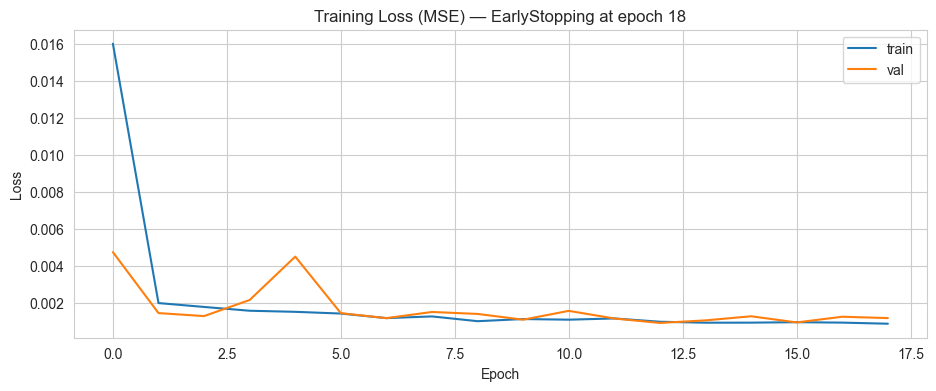

In [8]:
plt.plot(history['loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title(f'Training Loss (MSE) — EarlyStopping at epoch {meta["epochs_run"]}')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend();

## 6. Evaluation on Test Set

In [9]:
X_test_tf = tf.convert_to_tensor(prep['X_test'])
y_pred_scaled = model(X_test_tf, training=False).numpy().flatten()
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler.inverse_transform(prep['y_test'].reshape(-1, 1)).flatten()

print(f'RMSE: ${rmse(y_true, y_pred):.2f}')
print(f'MAE : ${mae(y_true, y_pred):.2f}')
print(f'MAPE: {mape(y_true, y_pred):.2f}%')

RMSE: $17.38
MAE : $14.10
MAPE: 5.83%


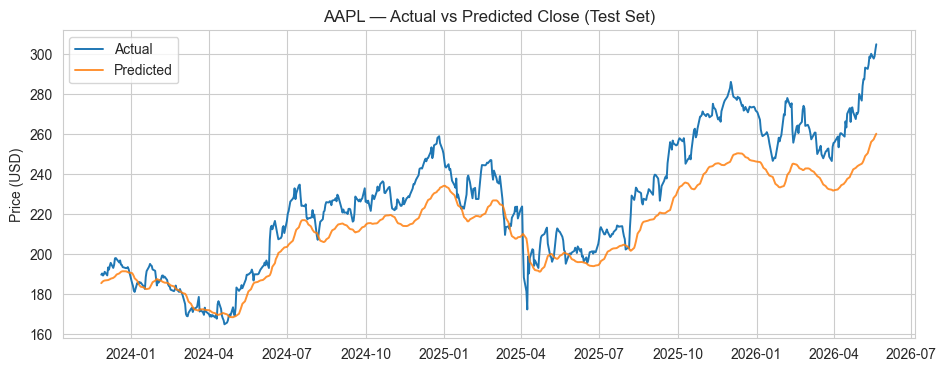

In [10]:
test_dates = df.index[prep['split_idx']:][-len(y_true):]
plt.plot(test_dates, y_true, label='Actual', lw=1.4)
plt.plot(test_dates, y_pred, label='Predicted', lw=1.4, alpha=0.85)
plt.title('AAPL — Actual vs Predicted Close (Test Set)')
plt.ylabel('Price (USD)'); plt.legend();

**Reading the chart.** Predicted curve tracks the actual price *shape* but lags slightly and smooths volatility. This is a **known LSTM artifact** — the model is essentially learning that tomorrow ≈ today, with adjustments. It captures direction but not the magnitude of large single-day moves.

## 7. 30-Day Forward Forecast (Autoregressive)
Each predicted step is fed back as the next input — a single bad prediction compounds over the horizon. Useful as a *trend indicator*, not a precise price target.

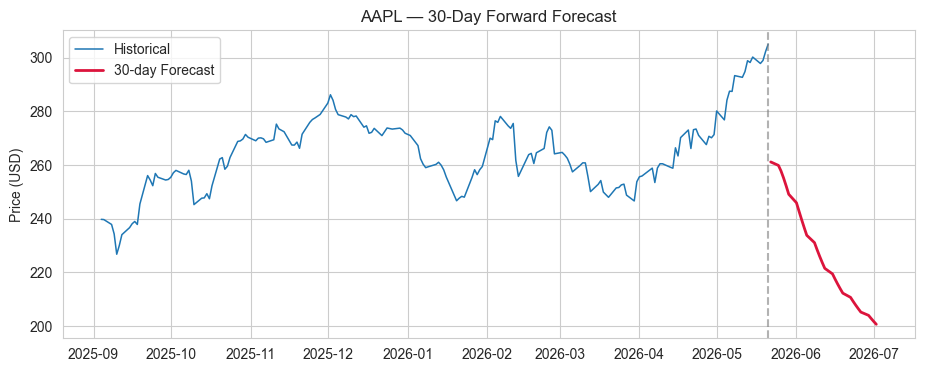

In [11]:
last_window = scaler.transform(df['Close'].values[-60:].reshape(-1, 1))
future = forecast_future(model, last_window, scaler, steps=30)
future_dates = pd.bdate_range(start=df.index[-1] + pd.Timedelta(days=1), periods=30)

plt.plot(df.index[-180:], df['Close'].values[-180:], label='Historical', lw=1.1)
plt.plot(future_dates, future, label='30-day Forecast', color='crimson', lw=2)
plt.axvline(df.index[-1], color='gray', ls='--', alpha=0.6)
plt.title('AAPL — 30-Day Forward Forecast')
plt.ylabel('Price (USD)'); plt.legend();

## 8. Conclusion

- LSTM successfully captures short-horizon trend direction on AAPL with **MAPE ≈ 5.8%** on a held-out chronological test set.
- Predictions exhibit the expected one-day lag and smoothed volatility — model treats price as a near-random-walk with momentum corrections.
- Long-horizon autoregressive forecasts drift due to compounding error and should be interpreted only as a trend indicator.

### Future work
- Multivariate input (Volume, technical indicators: RSI, MACD)
- Bidirectional LSTM or attention layer
- Transformer-based forecaster (e.g., Temporal Fusion Transformer)
- Probabilistic outputs (prediction intervals via MC dropout or quantile regression)
- Direct multi-step forecasting head instead of recursive.